# Raven — Meta-Labeling Classifier for the Peregrine Strategy (XAUUSD)

This notebook trains, validates, and exports **Raven**, a binary meta-labeling
classifier that decides whether a breakout signal generated by the **Peregrine**
MQL5 Expert Advisor is worth taking. The model does not predict price — it
predicts the probability that a signal Peregrine already generated will be a
winning trade, using the technical context at the moment of entry.

The notebook is deliberately kept close to how the analysis actually happened,
including three real data leakage bugs that were found and fixed during
development. That process is documented inline, and summarized in
`docs/02-data-leakage-findings.md`.


## Evaluation Helper Functions

Utility functions built on top of `yellowbrick` to visualize classifier
performance: confusion matrix, classification report, ROC/AUC curve,
precision-recall curve, and feature importances. These are reused throughout
the notebook to evaluate each candidate model consistently.


In [10]:
from yellowbrick.classifier import (
    ConfusionMatrix, ClassPredictionError, ClassificationReport,
    PrecisionRecallCurve, ROCAUC, ClassPredictionError
)
from yellowbrick.model_selection import FeatureImportances
from sklearn.metrics import roc_auc_score

# CLASSIFICATION ERROR PLOT
def plot_classification_error(model, X_val_test, y_val_test):
    fig, ax = plt.subplots(figsize = (7,6))
    cpe_viz = ClassPredictionError(
        model, 
        classes = [0, 1], 
        is_fitted=True, 
        force_model=True,
        ax=ax)
    cpe_viz.score(X_val_test, y_val_test)
    cpe_viz.show()

# CONFUSION MATRIX
def plot_confusion_matrix(model, X_train, y_train, X_val_test, y_val_test):
    fig, ax = plt.subplots(figsize = (5,5))
    cm = ConfusionMatrix(
        model,
        classes=['no', 'yes'],
        ax=ax
    )
    cm.fit(X_train, y_train)
    cm.score(X_val_test, y_val_test)
    cm.show();
    
# PRECISION, RECALL AND F1 CLASSIFICATION REPORT
def plot_classification_report(model,  X_train, y_train, X_val_test, y_val_test):
    fig, ax = plt.subplots(figsize = (6,5))
    visualizer = ClassificationReport(
        model,
        classes=['no', 'yes']
    )
    visualizer.fit(X_train, y_train)
    visualizer.score(X_val_test, y_val_test)
    visualizer.show();  
    
# PRECISION-RECALL CURVE
def plot_precision_recall_curve(model, X_train, y_train, X_val_test, y_val_test):
    fig, ax = plt.subplots(figsize = (6,6))
    viz = PrecisionRecallCurve(model)
    viz.fit(X_train, y_train)
    viz.score(X_val_test, y_val_test)
    viz.show();

# ROC CURVE (model performance across probability thresholds) and AUC (area under the curve)
def plot_roc_curve(model, X_train, y_train, X_val_test, y_val_test):
    fig, ax = plt.subplots(figsize = (6,6))
    roc_curves_visualizer = ROCAUC(
        model,
        classes=['no', 'yes']
    )
    roc_curves_visualizer.fit(X_train, y_train)
    roc_curves_visualizer.score(X_val_test, y_val_test) 
    roc_curves_visualizer.show();
    
# ROC AUC SCORE (how well the model separates the two classes)
def print_roc_auc_score(model, X_val_test, y_val_test):
    print(
        "roc_auc_score: {}".format(
            np.round(roc_auc_score(y_val_test, model.predict_proba(X_val_test)[:,1]), 3)
        )
    )

# CLASSIFY WITH A CUSTOM DECISION THRESHOLD (default 0.5)
def predict_with_threshold(model, X_val_test, threshold = 0.5):
    return np.where( model.predict_proba(X_val_test)[:,1] >= threshold, 1, 0 )

def plot_feature_importances(model, X_train, y_train, size_x, size_y):
    fig, ax = plt.subplots(figsize = (size_x,size_y))
    viz = FeatureImportances(model)
    viz.fit(X_train, y_train)
    viz.show();


# Model Training Pipeline

From this point on, the notebook builds Raven end to end: load the labeled
trade log produced by `Peregrine_collector.mq5`, aggregate it into one row
per trade, split it chronologically, train and compare several classifiers,
pick a probability threshold in a leak-free way, validate it with
walk-forward testing, and export the final model to ONNX for production.


## 1. Load and aggregate the trade log

`Peregrine_collector.mq5` writes **two rows per trade** to the CSV log: one
at entry time (with the technical features, and a placeholder `target = -1`
since the outcome is not known yet), and one at close time (with the real
`target` and `profit_real`, but the feature columns zeroed out). The
aggregation below collapses both rows into a single record per trade: the
entry features (`first`) combined with the real outcome and profit at close
(`last`). Rows where the trade never closed (`target == -1`) are dropped.



Trades by target
 target
1    484
0    353
Name: count, dtype: int64

Total trades: 837 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 837 entries, 0 to 836
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   target       837 non-null    int64  
 1   profit_real  837 non-null    float64
 2   bb_norm      837 non-null    float64
 3   adx          837 non-null    float64
 4   rsi          837 non-null    float64
 5   vol_rel      837 non-null    float64
 6   hour_sin     837 non-null    float64
 7   hour_cos     837 non-null    float64
 8   dist_MA      837 non-null    float64
 9   stch         837 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 65.5 KB


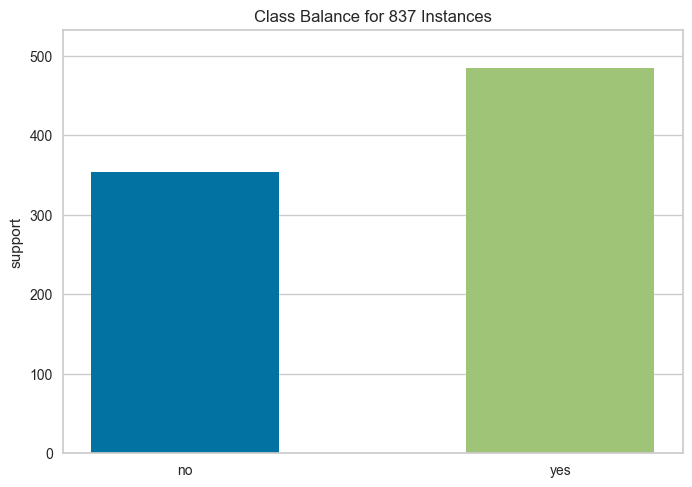

target         0
profit_real    0
bb_norm        0
adx            0
rsi            0
vol_rel        0
hour_sin       0
hour_cos       0
dist_MA        0
stch           0
dtype: int64


,target,profit_real,bb_norm,adx,rsi,vol_rel,hour_sin,hour_cos,dist_MA,stch
0,0,-499.2,1.388276,22.817380,68.347407,1.110603,0.965926,-0.258819,0.002684,1.583745
1,1,288.3,-0.011575,21.334741,41.057414,2.381211,-0.707107,-0.707107,-0.001797,1.795096
2,1,1281.6,-0.201673,18.641719,34.108649,1.704649,0.258819,-0.965926,-0.006392,2.102115
3,1,2277.6,-0.307786,18.641719,30.400000,1.174211,-0.258819,-0.965926,-0.008468,1.235206
4,1,1773.1,-0.236892,20.060271,20.155272,2.558992,-0.866025,-0.500000,-0.015512,1.555996


In [11]:
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from yellowbrick.target import ClassBalance

df_raw  = pd.read_csv("Logs/Peregrine_Data_Log.csv")

def aggregate_trades(dfraw):
    df = dfraw.groupby('ticket').agg({
        'target': 'last', 
        'profit_real': 'last',
        'bb_norm': 'first',
        'adx': 'first',
        'rsi': 'first',
        'vol_rel': 'first',
        'hour_sin': 'first',
        'hour_cos': 'first',
        'dist_MA': 'first',
        'stch': 'first'
    }).reset_index()
    return df    
df1 = aggregate_trades(df_raw)

df1 = df1[df1['target'] != -1]
print("\nTrades by target\n", df1['target'].value_counts())
print("\nTotal trades:", df1['target'].count(), "\n")

df = df1.drop(columns=['ticket'])
df.info()
df_final_train = df.copy()

class_visualizer = ClassBalance(labels=['no', 'yes'])
class_visualizer.fit(df.target)
class_visualizer.show() 
print(df.isnull().sum())
df.head()


## 2. Chronological train / validation / test split

Market data must **never** be split randomly — mixing time steps invalidates
any notion of "out-of-sample" evaluation. The dataset is split into three
chronological blocks instead of the usual two:

- **Train (60%)**: used to fit the candidate models.
- **Validation (20%)**: used **only** to choose the probability decision
  threshold. This is the block that closes the first data leakage bug found
  in this project — an earlier version of this notebook picked the threshold
  by scanning it directly against the test set, which quietly turned the
  "out-of-sample" test into part of the tuning process.
- **Test (20%)**: touched exactly once, at the very end, to report the final
  honest result.

`profit_real` is also carried through the split, kept separate from the
feature matrices — it is used later for the economic evaluation, never as a
model input (see the note on the second leakage bug further down).


In [12]:
FEATURE_COLS = ['bb_norm', 'adx', 'rsi', 'vol_rel', 'hour_sin', 'hour_cos', 'dist_MA', 'stch']

n_rows = len(df)
train_end = int(n_rows * 0.60)
val_end   = int(n_rows * 0.80)

train_set = df.iloc[:train_end]
val_set   = df.iloc[train_end:val_end]
test_set  = df.iloc[val_end:]

print(f"Train:      {len(train_set)} rows")
print(f"Validation: {len(val_set)} rows")
print(f"Test:       {len(test_set)} rows (never touched until the final evaluation)")

X_train = train_set[FEATURE_COLS].astype('float32')
y_train = train_set['target']
profit_train = train_set['profit_real']

X_val = val_set[FEATURE_COLS].astype('float32')
y_val = val_set['target']
profit_val = val_set['profit_real']

X_test = test_set[FEATURE_COLS].astype('float32')
y_test = test_set['target']
profit_test = test_set['profit_real']


Train:      502 rows
Validation: 167 rows
Test:       168 rows (never touched until the final evaluation)


## 3. Baseline model: a single Decision Tree

A simple, shallow Decision Tree is trained first as a baseline before
comparing more complex model families. `class_weight='balanced'` compensates
for the moderate class imbalance between winning and losing trades.


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
model = DecisionTreeClassifier(
    max_depth = 10, 
    min_samples_split = 10,
    class_weight = 'balanced', 	
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("F1 classification score:", f1_score(y_test, y_pred))


F1 classification score: 0.6192893401015228


## 4. Baseline diagnostics

Confusion matrix, precision/recall/F1 report, ROC/AUC curve, and feature
importances for the baseline Decision Tree.


c:\Users\verae\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


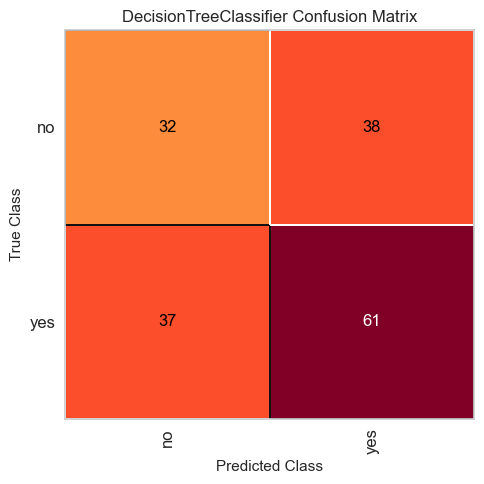

In [14]:
plot_confusion_matrix(model, X_train, y_train, X_test, y_test)

c:\Users\verae\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


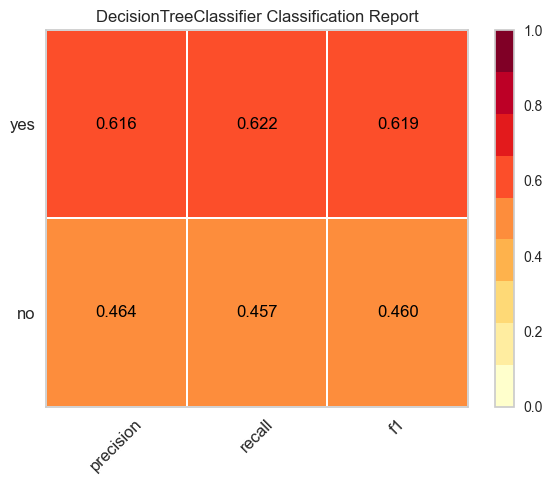

In [15]:
plot_classification_report(model, X_train, y_train, X_test, y_test)

c:\Users\verae\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


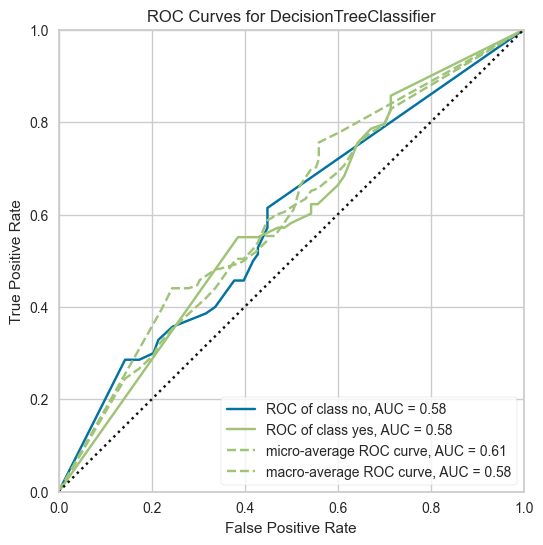

roc_auc_score: 0.584


In [16]:
plot_roc_curve(model, X_train, y_train, X_test, y_test)
print_roc_auc_score(model, X_test, y_test)


c:\Users\verae\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


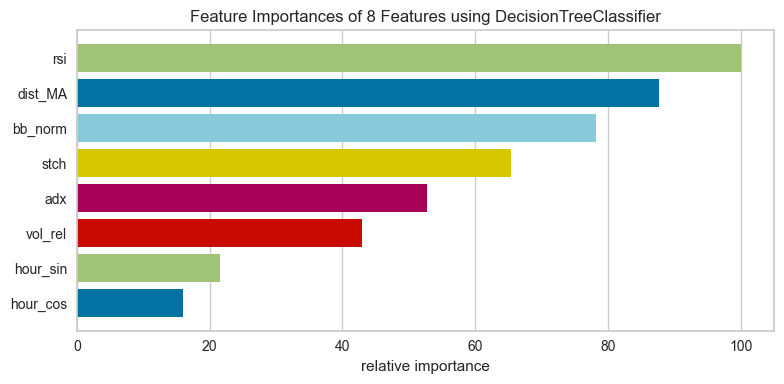


Global feature importance
  Indicator  Importance
2       rsi    0.215327
6   dist_MA    0.188954
0   bb_norm    0.168379
7      stch    0.140830
1       adx    0.113427
3   vol_rel    0.092339
4  hour_sin    0.046363
5  hour_cos    0.034381


In [17]:
plot_feature_importances(model, X_train, y_train, 8, 4)
print("\nGlobal feature importance")
importances = pd.DataFrame({
    'Indicator': df[FEATURE_COLS].columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importances)


## 5. Comparing model families with time-aware cross-validation

Four model families are compared: Decision Tree, Random Forest, XGBoost, and
LightGBM (the last two commented out here — they were evaluated separately
once a GPU configuration issue with `GridSearchCV`'s parallelism was
resolved). Hyperparameter search uses `TimeSeriesSplit` rather than a
standard k-fold, so every validation fold in the search is still strictly
after its corresponding training fold in time.


In [18]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm  import LGBMClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

models_params = {
    "DecisionTree": (
        DecisionTreeClassifier(random_state=42, class_weight = 'balanced'),
        {"max_depth": [4, 5, 7, 8],
         "min_samples_split": [8, 10, 20, 50]}
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42, class_weight = 'balanced', max_features = 'sqrt'),
        {"n_estimators": [50, 100, 300, 500],
         "max_depth": [4, 5, 7, 8],
         'min_samples_split': [8, 10, 20, 50],
         "min_samples_leaf": [1, 2, 4, 5]}
    # ),
    # "XGBoost": (
    #     XGBClassifier(random_state=42, eval_metric="logloss", tree_method="hist", device='cuda'),
    #     {"n_estimators": [100, 200, 300, 500],
    #      "max_depth": [4, 5, 7, 8],
    #      "subsample": [0.7, 0.8, 1],
    #      "scale_pos_weight": [0.8, 1],
    #      "learning_rate": [0.01, 0.05, 0.1, 0.2]}
    # ),
    #  "LightGBM": (
    #      LGBMClassifier(random_state=42, verbosity=-1),
    #     {"n_estimators": [100, 200, 300, 500],
    #      "max_depth": [4, 5, 7, 8],
    #      "scale_pos_weight": [0.8, 1],
    #      "learning_rate": [0.01, 0.05, 0.1, 0.2]}
    )
}
results = {}
saved_grids = {}

for name, (model, params) in models_params.items():
    # GPU-backed models (XGBoost) must run with n_jobs=1 in GridSearchCV:
    # parallel joblib workers each trying to init a CUDA context on the same
    # GPU causes contention and silent failures.
    n_jobs_grid = 1 if name == "XGBoost" else -1

    grid = GridSearchCV(
        model, 
        params, 
        scoring="f1", 
        return_train_score=True,
        cv=tscv, 
        n_jobs=n_jobs_grid
    )
    
    if name == "XGBoost":
        X_data = np.ascontiguousarray(X_train.values, dtype=np.float32)
        y_data = np.ascontiguousarray(y_train.values, dtype=np.int32)
    else:
        X_data = X_train
        y_data = y_train
        
    grid.fit(X_data, y_data)

    results[name] = (grid.best_score_, grid.best_params_)
    saved_grids[name] = grid
    print(f"{name} Best F1: {grid.best_score_:.4f} | Params: {grid.best_params_}")

best_name_model = max(results, key=lambda k: results[k][0]) # highest F1 score
print("The model with the highest F1 score is:", best_name_model)


DecisionTree Best F1: 0.5844 | Params: {'max_depth': 8, 'min_samples_split': 8}
RandomForest Best F1: 0.6343 | Params: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 50}
The model with the highest F1 score is: RandomForest


## 6. Traditional 0.50 threshold evaluation

A quick look at both trained models using the default 0.50 probability
threshold, before any threshold tuning takes place.


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

for name in ["DecisionTree", "RandomForest"]: #"XGBoost","LightGBM"
    best_model = saved_grids[name].best_estimator_
    traditional_predictions = best_model.predict(X_test)
    print("\nModel:", name)
    print("Evaluation with traditional threshold (0.50)")
    print(classification_report(y_test.values, traditional_predictions))
    print("Predictions: ", np.sum(best_model.predict(X_test)))
    cm = confusion_matrix(y_test.values, traditional_predictions)
    print("Confusion matrix with traditional threshold\n", cm)



Model: DecisionTree
Evaluation with traditional threshold (0.50)
              precision    recall  f1-score   support

           0       0.48      0.56      0.52        70
           1       0.64      0.57      0.61        98

    accuracy                           0.57       168
   macro avg       0.56      0.56      0.56       168
weighted avg       0.58      0.57      0.57       168

Predictions:  87
Confusion matrix with traditional threshold
 [[39 31]
 [42 56]]

Model: RandomForest
Evaluation with traditional threshold (0.50)
              precision    recall  f1-score   support

           0       0.58      0.40      0.47        70
           1       0.65      0.80      0.72        98

    accuracy                           0.63       168
   macro avg       0.62      0.60      0.60       168
weighted avg       0.62      0.63      0.62       168

Predictions:  120
Confusion matrix with traditional threshold
 [[28 42]
 [20 78]]


## 7. Model selection and stability check

**RandomForest is selected over DecisionTree**, even though a single Decision
Tree scored a higher F1 in earlier runs. A lone tree has higher variance than
an ensemble of many trees averaged together — with roughly 900 labeled
trades, a single tree is more likely to have fit a quirk of this particular
sample than a genuine pattern. The cell below checks the per-fold stability
of the chosen model directly: if the F1 score swings widely across the five
`TimeSeriesSplit` folds, that is a warning sign that the result should not be
trusted at face value.


In [20]:
model_elected = 'RandomForest' 
print('Selected model:', model_elected)
print('Parameters:', saved_grids[model_elected].best_params_)

final_model = saved_grids[model_elected].best_estimator_

# --- Model stability check (a single tree has higher variance than an
#     ensemble, so this is worth inspecting before trusting the result) ---
cv_results = saved_grids[model_elected].cv_results_
best_idx = saved_grids[model_elected].best_index_
fold_scores = [cv_results[f'split{i}_test_score'][best_idx] for i in range(5)]
print(f"F1 per fold (TimeSeriesSplit on train): {[round(s,3) for s in fold_scores]}")
print(f"Standard deviation across folds: {np.std(fold_scores):.3f}")
print("(If this deviation is large relative to the average F1, the tree is unstable")
print(" and it is safer to distrust the result or prefer RandomForest despite its lower F1)\n")


Selected model: RandomForest
Parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 50}
F1 per fold (TimeSeriesSplit on train): [np.float64(0.726), np.float64(0.598), np.float64(0.524), np.float64(0.652), np.float64(0.673)]
Standard deviation across folds: 0.069
(If this deviation is large relative to the average F1, the tree is unstable
 and it is safer to distrust the result or prefer RandomForest despite its lower F1)



## 8. Choosing the decision threshold — without leakage

This is where the first data leakage bug lived in an earlier version of this
project: the probability threshold was chosen by scanning candidate values
directly against the test set and keeping the one that maximized the
reported economic result. The moment any parameter is tuned by looking at a
dataset, that dataset stops being a fair out-of-sample test — even if the
model itself was never retrained on it.

The fix: the threshold search below only ever looks at `val_set`. It also
uses the **real logged profit per trade** (`profit_real`) rather than an
assumed fixed payout, and requires at least 10 trades to accept a candidate
threshold, so it can't lock onto a handful of lucky trades in a thin slice of
validation data.


In [21]:
prob_val = final_model.predict_proba(X_val)[:, 1]
sim_val = pd.DataFrame({
    'win_prob': prob_val,
    'target': y_val.values.astype('float32'),
    'profit_real': profit_val.values
})

print("--- Optimal threshold search (VALIDATION set only) ---")
best_threshold, best_result = None, -np.inf
threshold_results = []

for threshold in np.arange(0.30, 0.85, 0.05):
    allowed_trades = sim_val[sim_val['win_prob'] >= threshold]
    total_trades = len(allowed_trades)
    if total_trades >= 10:
        real_result = allowed_trades['profit_real'].sum()
        win_rate = (allowed_trades['target'] == 1).mean() * 100
        threshold_results.append((threshold, total_trades, win_rate, real_result))
        if real_result > best_result:
            best_result, best_threshold = real_result, threshold

for threshold, total, wr, result in threshold_results:
    marker = " <-- selected" if threshold == best_threshold else ""
    print(f"Threshold: {threshold:.2f} | Trades: {total} | WinRate: {wr:.1f}% | Result: ${result:,.0f}{marker}")

print(f"\nThreshold selected on VALIDATION: {best_threshold:.2f}")
print("This value is now FROZEN, it will not be adjusted again by looking at the test set.")


--- Optimal threshold search (VALIDATION set only) ---
Threshold: 0.30 | Trades: 154 | WinRate: 61.0% | Result: $57,253
Threshold: 0.35 | Trades: 150 | WinRate: 61.3% | Result: $56,450
Threshold: 0.40 | Trades: 141 | WinRate: 63.1% | Result: $57,955 <-- selected
Threshold: 0.45 | Trades: 115 | WinRate: 65.2% | Result: $52,287
Threshold: 0.50 | Trades: 99 | WinRate: 65.7% | Result: $47,906
Threshold: 0.55 | Trades: 79 | WinRate: 68.4% | Result: $46,197
Threshold: 0.60 | Trades: 53 | WinRate: 77.4% | Result: $39,356
Threshold: 0.65 | Trades: 43 | WinRate: 79.1% | Result: $33,956
Threshold: 0.70 | Trades: 22 | WinRate: 81.8% | Result: $16,000
Threshold: 0.75 | Trades: 11 | WinRate: 72.7% | Result: $7,117

Threshold selected on VALIDATION: 0.40
This value is now FROZEN, it will not be adjusted again by looking at the test set.


## 9. Final honest evaluation on the untouched test set

The frozen threshold from the previous step is applied to `test_set`
**exactly once**. This is the only number in the whole notebook that can
honestly be called an out-of-sample estimate of Raven's performance.


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

frozen_threshold = best_threshold

prob_test = final_model.predict_proba(X_test)[:, 1]
test_predictions = (prob_test >= frozen_threshold).astype(int)

print(f"FINAL evaluation on TEST with frozen threshold = {frozen_threshold:.2f}")
print(classification_report(y_test, test_predictions))

cm = confusion_matrix(y_test, test_predictions)
print("Confusion matrix (TEST, genuine out-of-sample):\n", cm)

# Economic result using profit_real, not a fixed assumed payout
test_trades = pd.DataFrame({
    'pred': test_predictions,
    'target': y_test.values,
    'profit_real': profit_test.values
})
taken_trades = test_trades[test_trades['pred'] == 1]
test_result = taken_trades['profit_real'].sum()

print(f"\nTrades taken in test: {len(taken_trades)}")
print(f"Won: {(taken_trades['target']==1).sum()} | Lost: {(taken_trades['target']==0).sum()}")
print(f"Economic result on TEST: ${test_result:,.0f}")


FINAL evaluation on TEST with frozen threshold = 0.40
              precision    recall  f1-score   support

           0       0.70      0.20      0.31        70
           1       0.62      0.94      0.75        98

    accuracy                           0.63       168
   macro avg       0.66      0.57      0.53       168
weighted avg       0.65      0.63      0.57       168

Confusion matrix (TEST, genuine out-of-sample):
 [[14 56]
 [ 6 92]]

Trades taken in test: 148
Won: 92 | Lost: 56
Economic result on TEST: $61,066


## 10. Retraining the production model

Before exporting to ONNX, the chosen model is refit one last time on **all**
available data (train + validation + test combined), so the version that
ships to production benefits from the full history, not just the 60% used
during model selection.

This step is where the **second data leakage bug** in this project lived:
an earlier version built `X` by dropping only the `target` column
(`df_train.drop(columns=['target'])`), which left `profit_real` inside the
feature matrix. Since `target` is derived directly from `profit_real`, the
model could trivially "predict" the outcome by reading the answer instead of
finding any real market pattern — it reported a perfect F1 score of 1.0.
The fix is the same one used for the train/validation/test split: select
`FEATURE_COLS` explicitly rather than dropping columns by name.


In [23]:
from sklearn.base import clone

df_train = df_final_train.copy()
X = df_train[FEATURE_COLS]
y = df_train['target']
model_ia = clone(saved_grids[model_elected].best_estimator_)
model_ia.fit(X, y)

print("Training data size: ", X.shape)  # must be (n, 8), not (n, 9)
print("\nTarget distribution across all training data:\n", train_set.target.value_counts(normalize=True))


Training data size:  (837, 8)

Target distribution across all training data:
 target
1    0.571713
0    0.428287
Name: proportion, dtype: float64


## 11. Exporting to ONNX for MetaTrader 5

The final classifier is converted to ONNX so it can run natively inside the
`Peregrine.mq5` Expert Advisor. Only the predicted label output is kept
(the probability output is dropped), matching the single-value output shape
the EA expects from `OnnxRun`.

This step is also where the **third bug** in this project was found: an
earlier version exported the model while it was still trained on 9 columns
(the `profit_real` leak from the previous section), while the ONNX graph
declared an 8-feature input. The mismatch meant every feature the EA sent at
inference time was read one position off from what the model actually
learned — in production, the filter ended up taking effectively 100% of the
signals, identical to having no filter at all, without raising any visible
error. Training `model_ia` on the explicit `FEATURE_COLS` (previous cell)
is what fixes it structurally; the assertion on `X.shape` above is the
guardrail against it happening again silently.


In [25]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType


initial_type = [('input', FloatTensorType([None, 8]))]
options = {type(model_ia): {'zipmap': False}}
onx = convert_sklearn(model_ia, initial_types=initial_type, options=options, target_opset=10)

for node in onx.graph.node:
    if node.op_type == "Binarizer":
        for attr in node.attribute:
            if attr.name == "threshold":
                attr.f = frozen_threshold

while len(onx.graph.output) > 1:
    onx.graph.output.pop(1)
# <PATH_TO_MT5_TERMINAL>
# NOTE: point this to your local MetaTrader 5 Files folder
with open(r"C:\Users\verae\AppData\Roaming\MetaQuotes\Terminal\D0E8209F77C8CF37AD8BF550E51FF075\MQL5\Experts\\Files\\Raven_for_Peregrine.onnx", "wb") as f:
    f.write(onx.SerializeToString())


## 12. Walk-forward validation

A single train/validation/test split, however carefully done, is still one
sample — a good or bad result from it can be a fold of luck as much as a
fold of skill. The two functions below implement a **rolling-window
walk-forward validation**: the training window has a fixed size and slides
forward in time (older data is dropped as new data is added, rather than
accumulating indefinitely), and no fold's test window ever overlaps with its
own training or validation window.

`walk_forward` reports Raven's result fold by fold. `walk_forward_comparative`
goes a step further and, for every fold, also computes what the result would
have been by taking **every** signal with no filter at all — this is the
real test of whether the meta-labeling layer adds value, rather than just
being profitable in isolation (a filtered subset of a profitable base
strategy is very often profitable too, filter or no filter).


In [ ]:
def evaluate_threshold(df_slice, probs, threshold, profit_col='profit_real', min_trades=10):
    mask = probs >= threshold
    n_trades = mask.sum()
    if n_trades < min_trades:
        return n_trades, None
    result = df_slice.loc[mask, profit_col].sum()
    return n_trades, result

def walk_forward(df, feature_cols, target_col='target', profit_col='profit_real',
                  train_window=400, val_window=80, test_window=60, step=60,
                  model_params=None, threshold_grid=np.arange(0.30, 0.85, 0.05)):
    """
    Rolling-window walk-forward validation (non-cumulative): each fold trains
    on the most recent 'train_window' rows, picks a threshold using the next
    'val_window' rows, and honestly evaluates on the 'test_window' rows after
    that -- strictly in the future relative to that fold's training data.
    """
    n = len(df)
    start = 0
    fold_results = []
    fold_num = 0

    while start + train_window + val_window + test_window <= n:
        fold_num += 1
        train_slice = df.iloc[start : start + train_window]
        val_slice   = df.iloc[start + train_window : start + train_window + val_window]
        test_slice  = df.iloc[start + train_window + val_window : start + train_window + val_window + test_window]

        X_tr, y_tr = train_slice[feature_cols], train_slice[target_col]
        X_va = val_slice[feature_cols]
        X_te = test_slice[feature_cols]

        model = RandomForestClassifier(random_state=42, class_weight='balanced', **(model_params or {}))
        model.fit(X_tr, y_tr)

        # choose the threshold using ONLY this fold's validation window
        prob_val = model.predict_proba(X_va)[:, 1]
        best_threshold, best_result = None, -np.inf
        for threshold in threshold_grid:
            n_v, result_v = evaluate_threshold(val_slice, prob_val, threshold, profit_col)
            if result_v is not None and result_v > best_result:
                best_result, best_threshold = result_v, threshold

        if best_threshold is None:
            best_threshold = 0.5  # fallback if no threshold gathers enough trades

        prob_test = model.predict_proba(X_te)[:, 1]
        n_test, test_result = evaluate_threshold(test_slice, prob_test, best_threshold, profit_col)

        fold_results.append({
            'fold': fold_num,
            'train_start': start,
            'threshold_chosen': best_threshold,
            'test_trades': n_test,
            'test_result': test_result if test_result is not None else 0.0
        })

        start += step

    return pd.DataFrame(fold_results)

def walk_forward_comparative(df, feature_cols, target_col='target', profit_col='profit_real',
                              train_window=400, val_window=80, test_window=60, step=30,
                              model_params=None, threshold_grid=np.arange(0.30, 0.85, 0.05)):
    """
    Same as walk_forward(), but also computes, for every fold, the result of
    taking ALL signals in the test window with no AI filter at all -- to
    directly compare whether Raven adds value or simply removes trades
    without genuine discrimination.
    """
    n = len(df)
    start = 0
    fold_results = []
    fold_num = 0

    while start + train_window + val_window + test_window <= n:
        fold_num += 1
        train_slice = df.iloc[start : start + train_window]
        val_slice   = df.iloc[start + train_window : start + train_window + val_window]
        test_slice  = df.iloc[start + train_window + val_window : start + train_window + val_window + test_window]

        X_tr, y_tr = train_slice[feature_cols], train_slice[target_col]
        X_va = val_slice[feature_cols]
        X_te = test_slice[feature_cols]

        model = RandomForestClassifier(random_state=42, class_weight='balanced', **(model_params or {}))
        model.fit(X_tr, y_tr)

        # choose the threshold using ONLY this fold's validation window
        prob_val = model.predict_proba(X_va)[:, 1]
        best_threshold, best_result = None, -np.inf
        for threshold in threshold_grid:
            mask = prob_val >= threshold
            if mask.sum() >= 10:
                result_v = val_slice.loc[mask, profit_col].sum()
                if result_v > best_result:
                    best_result, best_threshold = result_v, threshold
        if best_threshold is None:
            best_threshold = 0.5

        # WITH the Raven filter
        prob_test = model.predict_proba(X_te)[:, 1]
        mask_test = prob_test >= best_threshold
        n_test_filtered = mask_test.sum()
        filtered_result = test_slice.loc[mask_test, profit_col].sum() if n_test_filtered > 0 else 0.0

        # WITHOUT any filter (every signal in the fold)
        n_test_unfiltered = len(test_slice)
        unfiltered_result = test_slice[profit_col].sum()

        fold_results.append({
            'fold': fold_num,
            'train_start': start,
            'threshold_chosen': best_threshold,
            'trades_with_raven': n_test_filtered,
            'result_with_raven': filtered_result,
            'trades_no_filter': n_test_unfiltered,
            'result_no_filter': unfiltered_result,
            'raven_won': filtered_result > unfiltered_result
        })

        start += step

    return pd.DataFrame(fold_results)


### Walk-forward result (Raven only)

In [27]:
results = walk_forward(df_train, FEATURE_COLS, model_params=saved_grids[model_elected].best_params_)
print(results)
print("\nAverage threshold:", results['threshold_chosen'].mean(), "| std:", results['threshold_chosen'].std())
print("Total accumulated result:", results['test_result'].sum())
print("Folds with negative result:", (results['test_result'] < 0).sum(), "of", len(results))


   fold  train_start  threshold_chosen  test_trades  test_result
0     1            0              0.35           54     33615.19
1     2           60              0.30           54     13687.06
2     3          120              0.30           58     16131.78
3     4          180              0.30           60     16671.92
4     5          240              0.40           49      6689.39

Average threshold: 0.32999999999999996 | std: 0.04472135954999579
Total accumulated result: 86795.34
Folds with negative result: 0 of 5


### Walk-forward result: Raven vs. no filter (the real test)

This is the comparison that actually answers whether the meta-labeling layer
is worth its complexity. Across 5 rolling folds, Raven's filtered result
outperformed taking every signal in only 2 of 5 folds by count — but the
accumulated dollar total still favored Raven, almost entirely because of one
fold where it avoided what would otherwise have been a net losing stretch.
In every other fold, Raven barely filters anything (it lets through 90-100%
of the signals) or slightly hurts the result by excluding a few trades that
turned out to be winners.

**Honest conclusion**: as currently built, Raven behaves less like a
consistent quality filter and more like an occasional tail-risk brake. See
`docs/04-results-and-lessons-learned.md` for the full interpretation and the
next planned experiment (pooling correlated assets to grow the training
sample).


In [28]:
results = walk_forward_comparative(df_train, FEATURE_COLS, model_params=saved_grids[model_elected].best_params_)
print(results)
print("\nFolds where Raven beat no filter:", results['raven_won'].sum(), "of", len(results))


   fold  train_start  threshold_chosen  trades_with_raven  result_with_raven  \
0     1            0              0.35                 54           33615.19   
1     2           30              0.35                 46           14776.59   
2     3           60              0.30                 54           13687.06   
3     4           90              0.35                 50           15947.79   
4     5          120              0.30                 58           16131.78   
5     6          150              0.30                 59           26642.20   
6     7          180              0.30                 60           16671.92   
7     8          210              0.30                 58           -1907.38   
8     9          240              0.40                 49            6689.39   
9    10          270              0.55                 44           25692.68   

   trades_no_filter  result_no_filter  raven_won  
0                60          35116.07      False  
1                